# SmartPay4 Salary Prediction: Complete ML Pipeline in One Notebook

This notebook contains the full end-to-end machine learning workflow in a single file.

## Step-by-step workflow
1. Setup and imports
2. Load and validate dataset
3. Exploratory Data Analysis (EDA)
4. Feature engineering
5. Model benchmarking
6. Hyperparameter tuning
7. Final evaluation and artifact export
8. Single and batch prediction

All training, evaluation, and prediction steps are executed from this notebook only.

In [1]:
# Step 1: Setup and imports
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Resolve notebook project directory robustly
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd() / "new_smartpay",
]

ROOT = None
for candidate in CANDIDATE_ROOTS:
    if (candidate / "job_salary_prediction_dataset.csv").exists():
        ROOT = candidate
        break

if ROOT is None:
    raise FileNotFoundError("job_salary_prediction_dataset.csv not found in current folder or new_smartpay folder")

DATA_PATH = ROOT / "job_salary_prediction_dataset.csv"
MODEL_PATH = ROOT / "best_salary_regressor.pkl"
METRICS_PATH = ROOT / "model_metrics.json"
MODEL_COMPARISON_PATH = ROOT / "model_comparison.json"

REQUIRED_COLUMNS = [
    "job_title",
    "experience_years",
    "education_level",
    "skills_count",
    "industry",
    "company_size",
    "location",
    "remote_work",
    "certifications",
    "salary",
]

NUMERIC_FEATURES = [
    "experience_years",
    "skills_count",
    "certifications",
    "skills_experience_ratio",
    "remote_binary",
]

CATEGORICAL_FEATURES = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work",
    "experience_level",
]


def prepare_dataset(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    for col in ["job_title", "education_level", "industry", "company_size", "location", "remote_work"]:
        if col in frame.columns:
            frame[col] = frame[col].astype(str).str.strip().str.title()

    frame["experience_level"] = pd.cut(
        frame["experience_years"],
        bins=[0, 3, 7, 12, 20, 100],
        labels=["Junior", "Mid", "Experienced", "Senior", "Lead"],
        right=False,
    )
    frame["skills_experience_ratio"] = (frame["skills_count"] + 1) / (frame["experience_years"] + 1)
    frame["is_high_certified"] = (frame["certifications"] > 2).astype(int)
    frame["remote_binary"] = frame["remote_work"].map({"No": 0, "Hybrid": 1, "Yes": 1}).fillna(0)
    return frame


def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def evaluate_model(name: str, pipeline: Pipeline, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    preds = pipeline.predict(X_test)
    return {
        "model": name,
        "mae": float(mean_absolute_error(y_test, preds)),
        "rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
        "r2": float(r2_score(y_test, preds)),
    }


print(f"Working directory for pipeline: {ROOT}")

Working directory for pipeline: c:\Users\Siddharth\Desktop\7th Sem\SmartPay\new_smartpay


In [2]:
# Step 2: Load and validate dataset
raw_df = pd.read_csv(DATA_PATH)
missing_columns = [col for col in REQUIRED_COLUMNS if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

raw_df = raw_df[REQUIRED_COLUMNS].copy()

print("Dataset shape:", raw_df.shape)
print(raw_df.head().to_string(index=False))
print("\nColumns:", list(raw_df.columns))
print("\nMissing values:\n", raw_df.isnull().sum().to_dict())
print("\nSalary summary:\n", raw_df["salary"].describe().to_string())

Dataset shape: (250000, 10)
         job_title  experience_years education_level  skills_count      industry company_size  location remote_work  certifications  salary
       AI Engineer                10        Bachelor             2    Healthcare       Medium     India      Hybrid               2  109413
      Data Analyst                 5        Bachelor            17       Telecom        Small Australia          No               0   93764
Frontend Developer                18             PhD             4         Media       Medium Singapore          No               1  148123
  Business Analyst                19             PhD            13        Retail       Medium    Canada         Yes               0  189123
   Product Manager                15        Bachelor             7 Manufacturing        Large    Sweden         Yes               0  165069

Columns: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work'

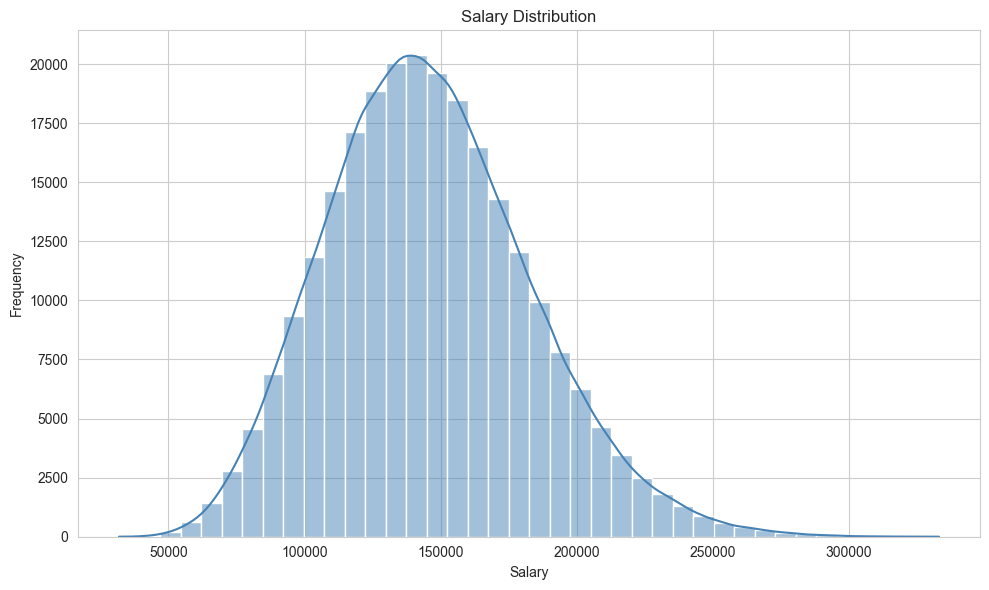

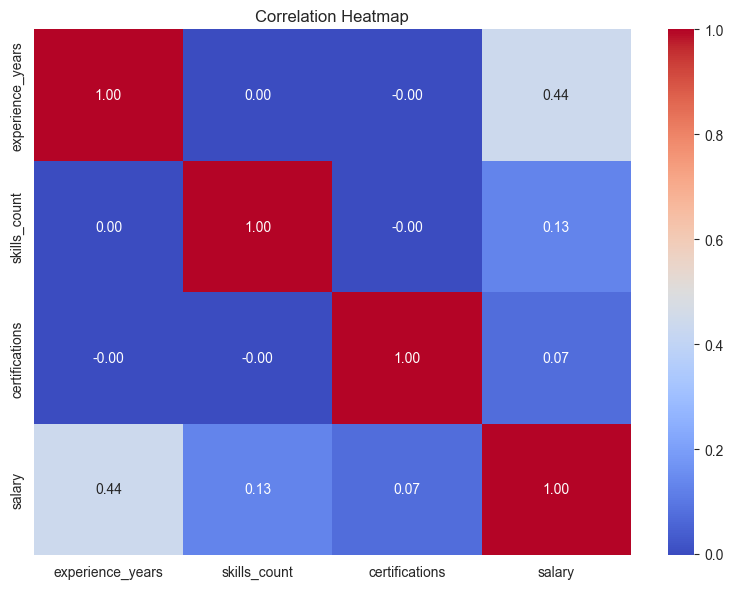

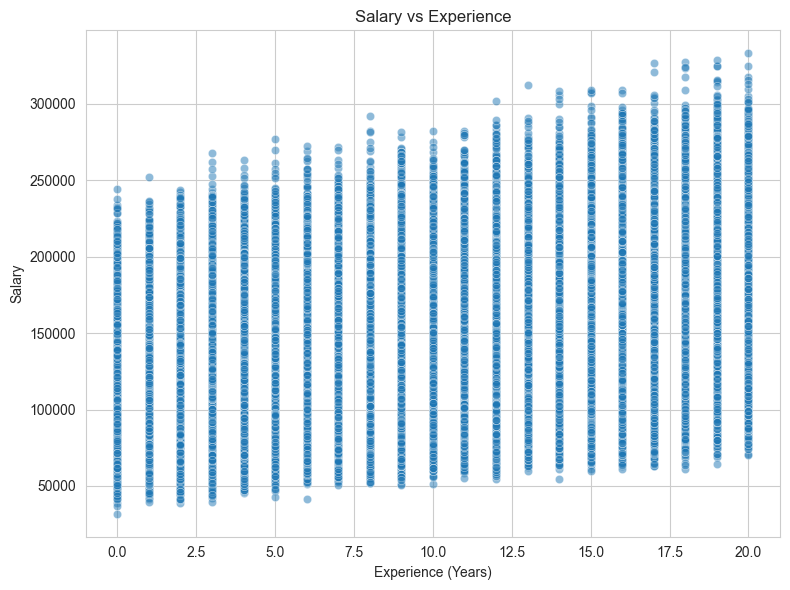

EDA complete. Charts displayed and saved.


In [3]:
# Step 3: Exploratory Data Analysis (EDA)

# Salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(raw_df["salary"], bins=40, kde=True, color="steelblue")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
plt.savefig(ROOT / "salary_distribution.png", dpi=300)
plt.close()

# Correlation heatmap
corr = raw_df[["experience_years", "skills_count", "certifications", "salary"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.savefig(ROOT / "correlation_heatmap.png", dpi=300)
plt.close()

# Salary vs experience
plt.figure(figsize=(8, 6))
sns.scatterplot(data=raw_df, x="experience_years", y="salary", alpha=0.5)
plt.title("Salary vs Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()
plt.savefig(ROOT / "salary_vs_experience.png", dpi=300)
plt.close()

print("EDA complete. Charts displayed and saved.")

In [4]:
# Step 4: Feature engineering
df = prepare_dataset(raw_df)

print("Feature-engineered dataset preview:")
print(df.head().to_string(index=False))

print("\nEngineered columns added:")
print(["experience_level", "skills_experience_ratio", "is_high_certified", "remote_binary"])

Feature-engineered dataset preview:
         job_title  experience_years education_level  skills_count      industry company_size  location remote_work  certifications  salary experience_level  skills_experience_ratio  is_high_certified  remote_binary
       Ai Engineer                10        Bachelor             2    Healthcare       Medium     India      Hybrid               2  109413      Experienced                 0.272727                  0              1
      Data Analyst                 5        Bachelor            17       Telecom        Small Australia          No               0   93764              Mid                 3.000000                  0              0
Frontend Developer                18             Phd             4         Media       Medium Singapore          No               1  148123           Senior                 0.263158                  0              0
  Business Analyst                19             Phd            13        Retail       Medium    Can


🚀 MODEL 1/4: Linear Regression
⏳ [Linear Regression] Starting preprocessing + training...
✅ [Linear Regression] Training completed!
⏱️ [Linear Regression] Training time: 0.01 minutes
📊 [Linear Regression] Evaluating...
✅ [Linear Regression] Evaluation completed in 0.11 seconds
📈 [Linear Regression] R² Score: 0.9635
⏱️ [Linear Regression] Total time: 0.01 minutes
🏁 [Linear Regression] FINISHED

🚀 MODEL 2/4: Ridge
⏳ [Ridge] Starting preprocessing + training...
✅ [Ridge] Training completed!
⏱️ [Ridge] Training time: 0.01 minutes
📊 [Ridge] Evaluating...
✅ [Ridge] Evaluation completed in 0.08 seconds
📈 [Ridge] R² Score: 0.9635
⏱️ [Ridge] Total time: 0.01 minutes
🏁 [Ridge] FINISHED

🚀 MODEL 3/4: Lasso
⏳ [Lasso] Starting preprocessing + training...
✅ [Lasso] Training completed!
⏱️ [Lasso] Training time: 1.45 minutes
📊 [Lasso] Evaluating...
✅ [Lasso] Evaluation completed in 0.10 seconds
📈 [Lasso] R² Score: 0.9635
⏱️ [Lasso] Total time: 1.45 minutes
🏁 [Lasso] FINISHED

🚀 MODEL 4/4: 
    "Rando

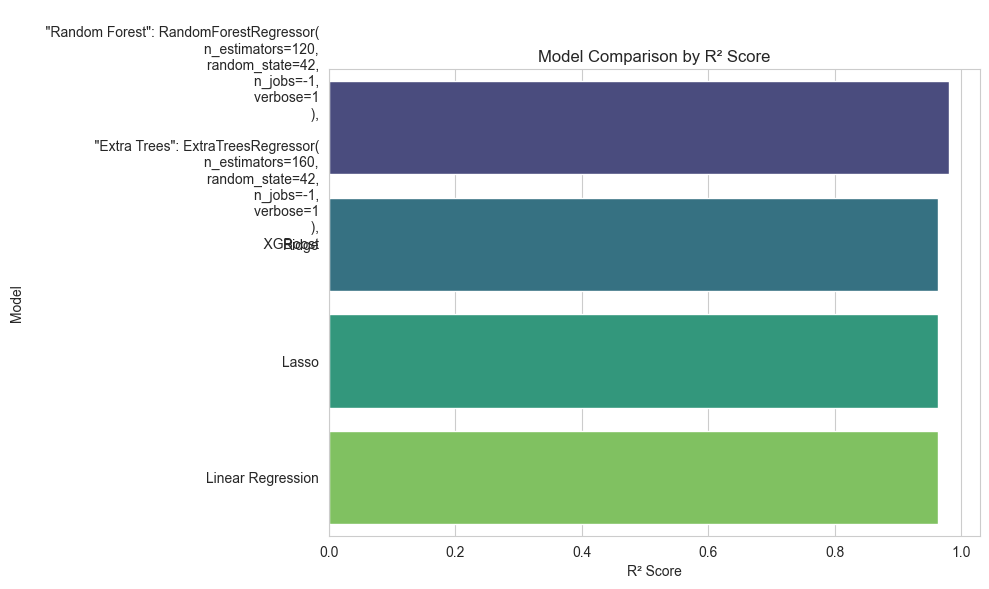


🏆 Best candidate from benchmark: 
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=160,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ),
    XGBoost


In [5]:
# Step 5: Model benchmarking

import time

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

preprocessor = build_preprocessor()

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
'''
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=160,
        random_state=42,
        n_jobs=-1,
        verbose=1
    ),
    '''
    "XGBoost": XGBRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=1,
    ),
}

results = []

# Total benchmark timer
benchmark_start = time.time()

total_models = len(candidate_models)

for model_number, (model_name, estimator) in enumerate(
    candidate_models.items(), start=1
):

    print("\n" + "=" * 70, flush=True)
    print(
        f"🚀 MODEL {model_number}/{total_models}: {model_name}",
        flush=True
    )
    print("=" * 70, flush=True)

    model_start = time.time()

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    print(
        f"⏳ [{model_name}] Starting preprocessing + training...",
        flush=True
    )

    # Train model
    pipeline.fit(X_train, y_train)

    training_time = time.time() - model_start

    print(
        f"✅ [{model_name}] Training completed!",
        flush=True
    )

    print(
        f"⏱️ [{model_name}] Training time: "
        f"{training_time / 60:.2f} minutes",
        flush=True
    )

    # Evaluation
    print(
        f"📊 [{model_name}] Evaluating...",
        flush=True
    )

    evaluation_start = time.time()

    result = evaluate_model(
        model_name,
        pipeline,
        X_test,
        y_test
    )

    evaluation_time = time.time() - evaluation_start

    results.append(result)

    print(
        f"✅ [{model_name}] Evaluation completed "
        f"in {evaluation_time:.2f} seconds",
        flush=True
    )

    # Display R² immediately
    if "r2" in result:
        print(
            f"📈 [{model_name}] R² Score: "
            f"{result['r2']:.4f}",
            flush=True
        )

    print(
        f"⏱️ [{model_name}] Total time: "
        f"{(time.time() - model_start) / 60:.2f} minutes",
        flush=True
    )

    print(
        f"🏁 [{model_name}] FINISHED",
        flush=True
    )


# ============================================================
# FINAL RESULTS
# ============================================================

total_time = time.time() - benchmark_start

print("\n" + "=" * 70, flush=True)
print("🏆 ALL MODELS COMPLETED", flush=True)
print("=" * 70, flush=True)

print(
    f"⏱️ Total benchmark time: "
    f"{total_time / 60:.2f} minutes",
    flush=True
)

comparison_df = pd.DataFrame(results).sort_values(
    "r2",
    ascending=False
)

print("\n📊 MODEL COMPARISON:")
print(
    comparison_df.to_string(index=False),
    flush=True
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_df,
    x="r2",
    y="model",
    palette="viridis"
)

plt.title("Model Comparison by R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(
    ROOT / "model_comparison.png",
    dpi=300
)

plt.show()
plt.close()


print(
    "\n🏆 Best candidate from benchmark:",
    comparison_df.iloc[0]["model"],
    flush=True
)

Running hyperparameter tuning...

Final metrics:
{
  "best_model": "XGBoostRegressor",
  "best_params": {
    "model__subsample": 0.9,
    "model__reg_lambda": 2.0,
    "model__reg_alpha": 1.0,
    "model__n_estimators": 350,
    "model__max_depth": 6,
    "model__learning_rate": 0.05,
    "model__colsample_bytree": 1.0
  },
  "mae": 4100.8843,
  "rmse": 5143.5315,
  "r2": 0.981,
  "dataset_rows": 250000,
  "train_rows": 200000,
  "test_rows": 50000,
  "model_results": [
    {
      "model": "\n    \"Random Forest\": RandomForestRegressor(\n        n_estimators=120,\n        random_state=42,\n        n_jobs=-1,\n        verbose=1\n    ),\n\n    \"Extra Trees\": ExtraTreesRegressor(\n        n_estimators=160,\n        random_state=42,\n        n_jobs=-1,\n        verbose=1\n    ),\n    XGBoost",
      "mae": 4160.705078125,
      "rmse": 5220.374699195451,
      "r2": 0.9803920984268188
    },
    {
      "model": "Ridge",
      "mae": 5436.185061010914,
      "rmse": 7125.723625670277,

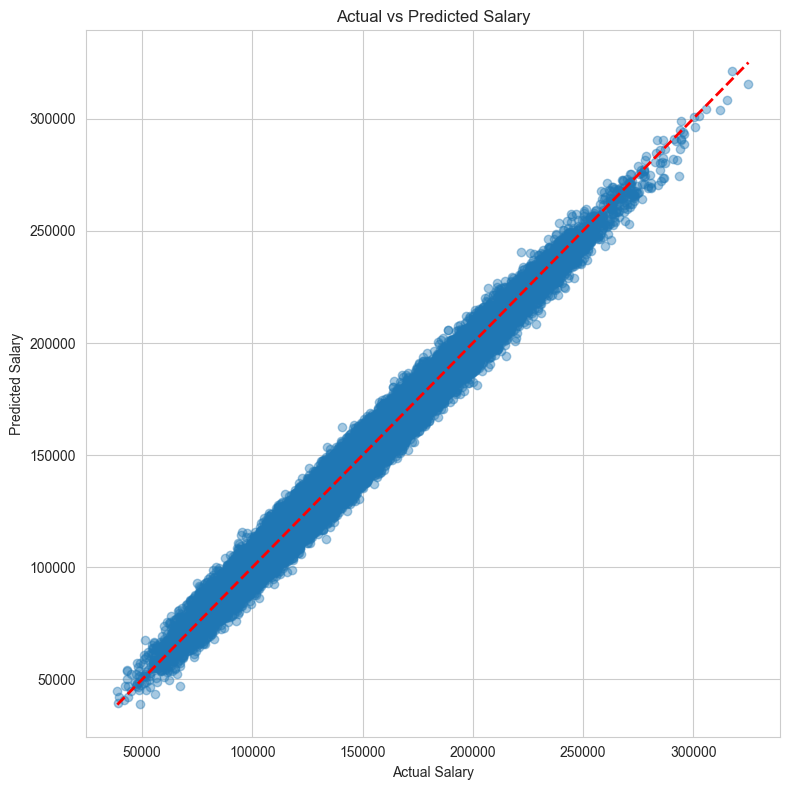

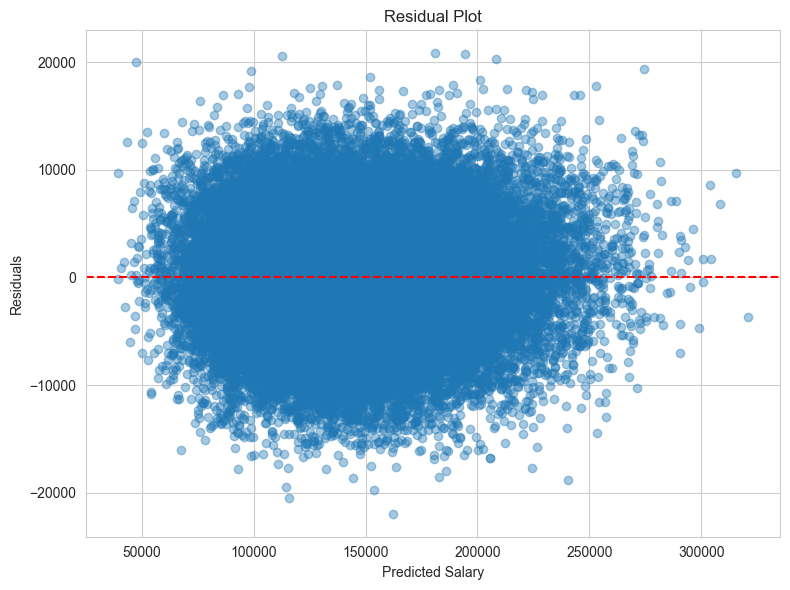

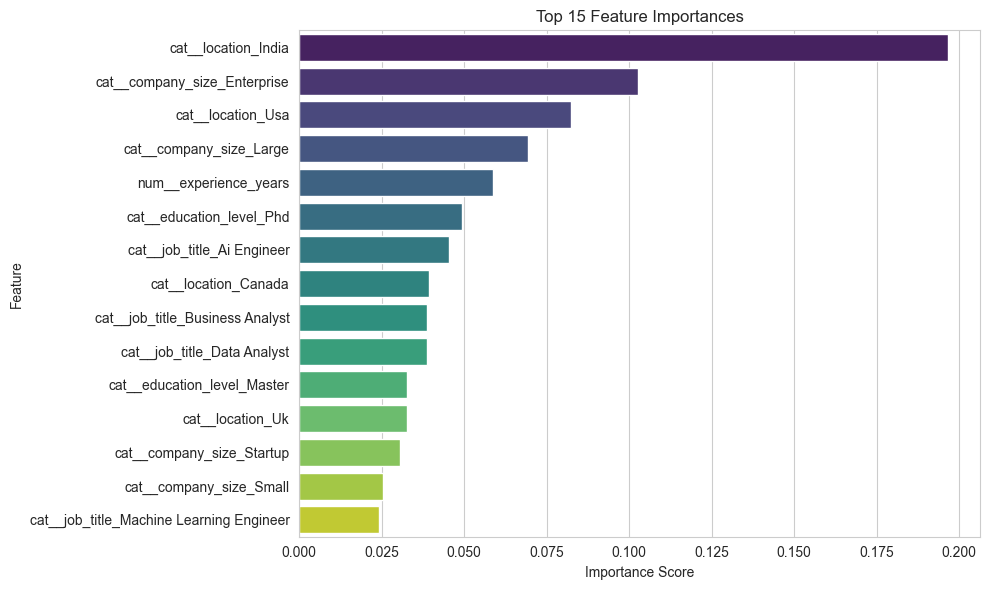


Model saved at: c:\Users\Siddharth\Desktop\7th Sem\SmartPay\new_smartpay\best_salary_regressor.pkl
Metrics saved at: c:\Users\Siddharth\Desktop\7th Sem\SmartPay\new_smartpay\model_metrics.json
Model comparison saved at: c:\Users\Siddharth\Desktop\7th Sem\SmartPay\new_smartpay\model_comparison.json


In [6]:
# Step 6: Hyperparameter tuning, evaluation, and export
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [150, 250, 350],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [4, 6],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_dist,
    n_iter=4,
    scoring="r2",
    cv=2,
    random_state=42,
    n_jobs=-1,
)

print("Running hyperparameter tuning...")
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

metrics = {
    "best_model": "XGBoostRegressor",
    "best_params": search.best_params_,
    "mae": round(float(final_mae), 4),
    "rmse": round(float(final_rmse), 4),
    "r2": round(float(final_r2), 4),
    "dataset_rows": int(len(df)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "model_results": comparison_df.to_dict(orient="records"),
}

print("\nFinal metrics:")
print(json.dumps(metrics, indent=2))

# Actual vs predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("Actual vs Predicted Salary")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.tight_layout()
plt.show()
plt.savefig(ROOT / "actual_vs_predicted.png", dpi=300)
plt.close()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()
plt.savefig(ROOT / "residuals_plot.png", dpi=300)
plt.close()

# Feature importance (for tree-based model)
model = best_pipeline.named_steps["model"]
if hasattr(model, "feature_importances_"):
    transformed_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=[transformed_names[i] for i in indices], palette="viridis")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    plt.savefig(ROOT / "feature_importance.png", dpi=300)
    plt.close()

# Save artifacts generated by notebook
joblib.dump(best_pipeline, MODEL_PATH)
with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
with open(MODEL_COMPARISON_PATH, "w", encoding="utf-8") as f:
    json.dump(comparison_df.to_dict(orient="records"), f, indent=2)

print(f"\nModel saved at: {MODEL_PATH}")
print(f"Metrics saved at: {METRICS_PATH}")
print(f"Model comparison saved at: {MODEL_COMPARISON_PATH}")

In [7]:
# Step 7: Single and batch prediction inside notebook

def predict_salary(input_frame: pd.DataFrame) -> pd.Series:
    prepared = prepare_dataset(input_frame)
    return pd.Series(best_pipeline.predict(prepared[NUMERIC_FEATURES + CATEGORICAL_FEATURES]))

# Single example prediction
single_input = pd.DataFrame([
    {
        "job_title": "Software Engineer",
        "experience_years": 7,
        "education_level": "Bachelor",
        "skills_count": 12,
        "industry": "Technology",
        "company_size": "Medium",
        "location": "India",
        "remote_work": "Hybrid",
        "certifications": 3,
    }
])

single_prediction = predict_salary(single_input).iloc[0]
print(f"Single prediction: Rs {single_prediction:,.2f}")

# Batch prediction from CSV (if file exists)
batch_path = ROOT / "batch_input.csv"
if batch_path.exists():
    batch_df = pd.read_csv(batch_path)
    required_input_cols = [
        "job_title",
        "experience_years",
        "education_level",
        "skills_count",
        "industry",
        "company_size",
        "location",
        "remote_work",
        "certifications",
    ]

    missing_input = [c for c in required_input_cols if c not in batch_df.columns]
    if missing_input:
        print(f"batch_input.csv is missing columns: {missing_input}")
    else:
        predictions = predict_salary(batch_df)
        batch_output = batch_df.copy()
        batch_output["predicted_salary"] = predictions
        output_path = ROOT / "batch_predictions.csv"
        batch_output.to_csv(output_path, index=False)
        print(f"Batch predictions saved at: {output_path}")
        print(batch_output.head().to_string(index=False))
else:
    print("batch_input.csv not found. Create it in the same folder to run batch prediction.")

print("Notebook pipeline is complete and self-contained.")

Single prediction: Rs 84,049.44
batch_input.csv not found. Create it in the same folder to run batch prediction.
Notebook pipeline is complete and self-contained.
